In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [12]:
def Perceptron(x, y, theta, theta_0, n):
    for i in range(n):
        for j in range(len(x)):
            if y[j] * (np.dot(theta, x[j]) + theta_0) <= 0:
                theta += y[j] * x[j]
                theta_0 += y[j]
    return theta, theta_0

In [13]:
n = 10 # Number of iterations of the algorithm
s = 200 # Number of samples
test_size = 0.2 # Proportion of the dataset to include in the test split

theta, theta_0 = np.zeros(2), 0
x, y = make_blobs(n_samples=s, centers=2, random_state=42)
# Fix labels to be -1 and 1 instead of 0 and 1
y = np.where(y == 0, -1, 1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42)

best_theta_train, best_theta_0_train = Perceptron(x_train, y_train, theta, theta_0, n)

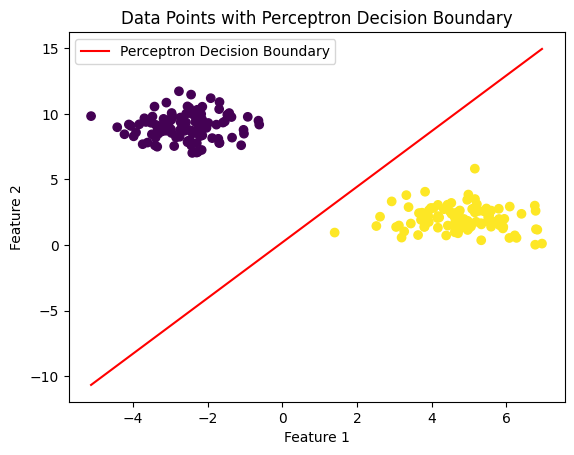

In [14]:
# Plot the points
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data Points with Perceptron Decision Boundary')
# Plot the decision boundary
x_values = np.linspace(min(x[:, 0]), max(x[:, 0]), 100)
y_values = -(best_theta_train[0] * x_values + best_theta_0_train) / best_theta_train[1]
plt.plot(x_values, y_values, color='red', label='Perceptron Decision Boundary')
plt.legend()
plt.show()

Accuracy on test set: 1.00


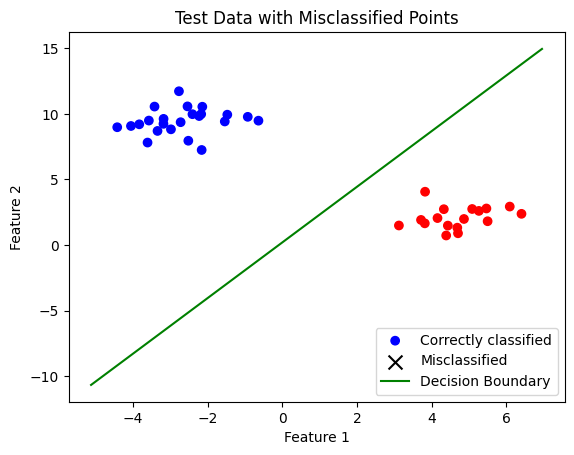

In [15]:
# Plotting the decision boundary for test data
y_pred = []

for xi in x_test:
    val = np.dot(best_theta_train, xi) + best_theta_0_train
    y_pred.append(1 if val > 0 else -1)
accuracy = np.mean(y_pred == y_test)
print(f'Accuracy on test set: {accuracy:.2f}')

y_pred = np.array(y_pred)

# Find misclassified points
misclassified = (y_pred != y_test)

# Plot correctly classified points
plt.scatter(
    x_test[~misclassified][:, 0],
    x_test[~misclassified][:, 1],
    c=y_test[~misclassified],
    cmap='bwr',
    label='Correctly classified'
)

# Plot misclassified points
plt.scatter(
    x_test[misclassified][:, 0],
    x_test[misclassified][:, 1],
    color='black',
    marker='x',
    s=100,
    label='Misclassified'
)

# Plot decision boundary
x_values = np.linspace(min(x[:, 0]), max(x[:, 0]), 100)

if best_theta_train[1] != 0:
    y_values = -(best_theta_train[0] * x_values + best_theta_0_train) / best_theta_train[1]
    plt.plot(x_values, y_values, color='green', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Test Data with Misclassified Points')
plt.legend()
plt.show()